In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

X_scaled = pd.read_csv("../data/customer_scaled_features.csv")
X_pca = pd.read_csv("../data/customer_pca_features.csv")

print("Scaled feature shape:", X_scaled.shape)
print("PCA feature shape:", X_pca.shape)

Scaled feature shape: (1000, 4)
PCA feature shape: (1000, 3)


In [2]:
k_values = range(2, 9)

inertia_values = []
silhouette_values = []
davies_bouldin_values = []
calinski_harabasz_values = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(
        silhouette_score(X_scaled, labels)
    )
    davies_bouldin_values.append(
        davies_bouldin_score(X_scaled, labels)
    )
    calinski_harabasz_values.append(
        calinski_harabasz_score(X_scaled, labels)
    )

print("Evaluation completed.")

Evaluation completed.


In [3]:
results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette": silhouette_values,
    "Davies_Bouldin": davies_bouldin_values,
    "Calinski_Harabasz": calinski_harabasz_values
})

results

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,2589.970556,0.305956,1.294005,543.334247
1,3,2148.526232,0.265769,1.331303,429.578033
2,4,1766.661769,0.258836,1.348525,419.700197
3,5,1536.291753,0.257006,1.226626,398.920737
4,6,1319.454017,0.266994,1.151962,403.873522
5,7,1172.189329,0.275107,1.049762,399.255184
6,8,1053.404709,0.265460,1.107399,396.404766


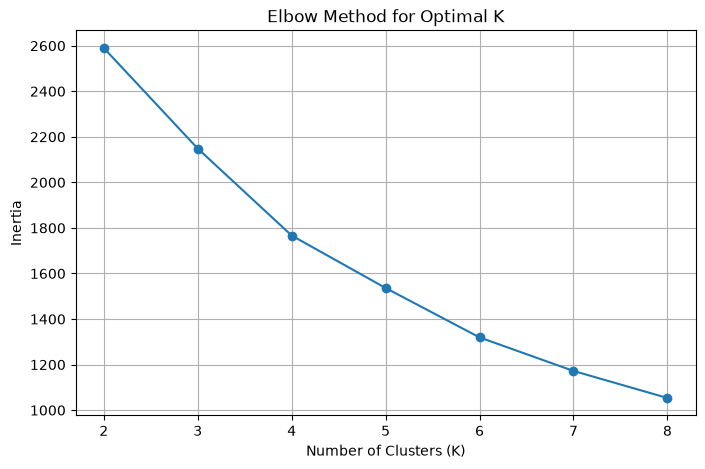

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

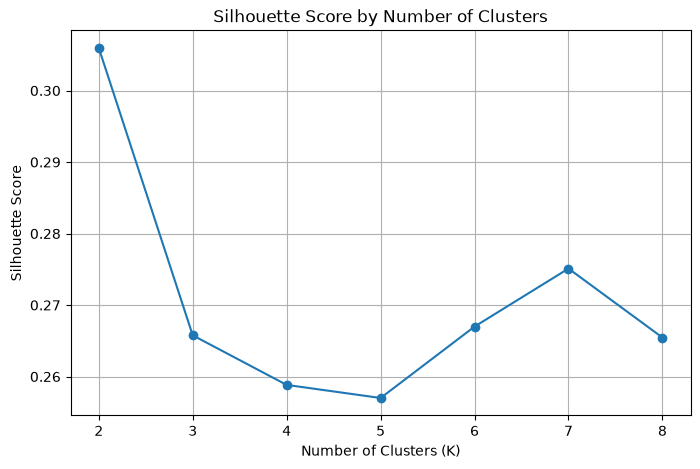

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

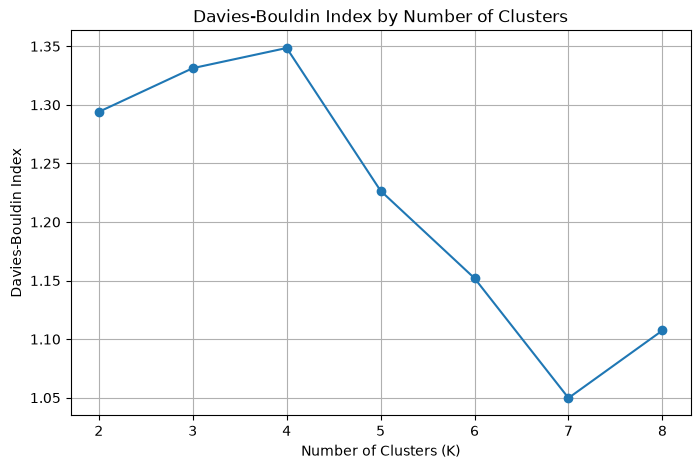

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Davies_Bouldin"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

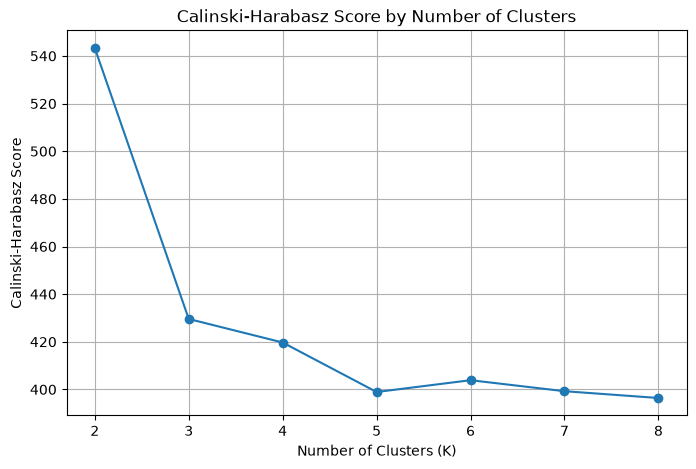

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Calinski_Harabasz"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [8]:
k_values = range(2, 9)

pca_inertia = []
pca_silhouette = []
pca_davies_bouldin = []
pca_calinski_harabasz = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    pca_inertia.append(kmeans.inertia_)

    pca_silhouette.append(
        silhouette_score(X_pca, labels)
    )

    pca_davies_bouldin.append(
        davies_bouldin_score(X_pca, labels)
    )

    pca_calinski_harabasz.append(
        calinski_harabasz_score(X_pca, labels)
    )

print("PCA clustering evaluation completed.")

PCA clustering evaluation completed.


In [9]:
pca_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": pca_inertia,
    "Silhouette": pca_silhouette,
    "Davies_Bouldin": pca_davies_bouldin,
    "Calinski_Harabasz": pca_calinski_harabasz
})

pca_results

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,2516.713425,0.312335,1.273554,559.009483
1,3,2075.364957,0.272670,1.289660,444.613545
2,4,1693.992470,0.267509,1.316469,437.519992
3,5,1462.498198,0.268611,1.181302,419.072503
4,6,1248.033925,0.277953,1.116117,426.636594
5,7,1102.813582,0.286717,1.019538,423.735889
6,8,984.061813,0.278751,1.061541,423.723142


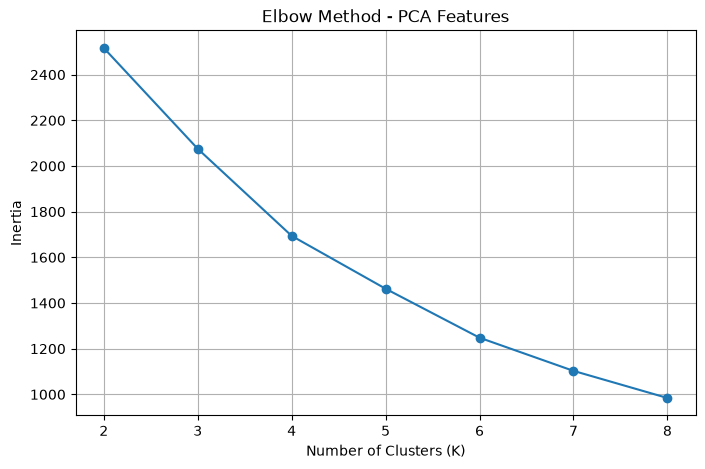

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    pca_results["K"],
    pca_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - PCA Features")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

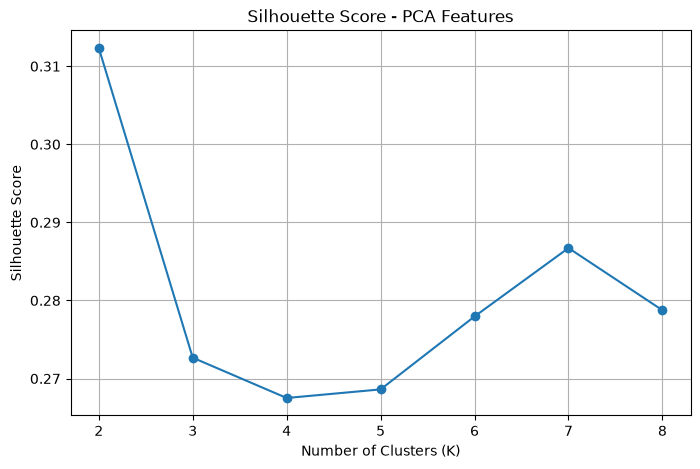

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    pca_results["K"],
    pca_results["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - PCA Features")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [12]:
final_k = 2

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_pca)

print("Final K-Means model trained.")
print("Number of clusters:", final_k)

Final K-Means model trained.
Number of clusters: 2


In [13]:
cluster_counts = pd.Series(final_labels).value_counts().sort_index()

print("Customers per cluster:")
print(cluster_counts)

Customers per cluster:
0    511
1    489
Name: count, dtype: int64


In [14]:
customer_clusters = pd.read_csv("../data/customer_cleaned.csv")

customer_clusters["cluster"] = final_labels

customer_clusters.head()

,name,age,gender,education,income,country,purchase_frequency,annual_spending,cluster
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,0
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,0
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,1
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,1
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,0


In [15]:
customer_clusters.to_csv(
    "../data/customer_clustered.csv",
    index=False
)

print("Clustered customer data saved successfully.")

Clustered customer data saved successfully.
